# Breast Cancer Detection Pipeline
**Goal:** Build a Random Forest to predict if a tumor is Malignant or Benign based on cell nucleus measurements.
**Dataset:** `load_breast_cancer` from `sklearn.datasets`

In [1]:
# 1. Import our tools
import pandas as pd 
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Bioinformatics Tools Loaded")

Bioinformatics Tools Loaded


## Loading and Exporting data

In [2]:
data=load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] =data.target
a=df.head()

b=df['target'].shape

c=df['target'].isnull().sum()

print(f"show first 5 rows:\n {a}")

print(f"\n shape of data: {b}")

print(f"\n how many boxes are blank with no information: {c}")

show first 5 rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst ar

In [3]:
X=df.drop('target',axis=1)     # Isolate the features by dropping the target column

Y=df["target"]    # want to predict

X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2)

In [4]:
cancer_modle=RandomForestClassifier(random_state=42)

cancer_modle.fit(X_train,Y_train)

predictions=cancer_modle.predict(X_test)

e=accuracy_score(Y_test,predictions)

print(f"accuracy= {e*100:.3f}%")

accuracy= 94.737%


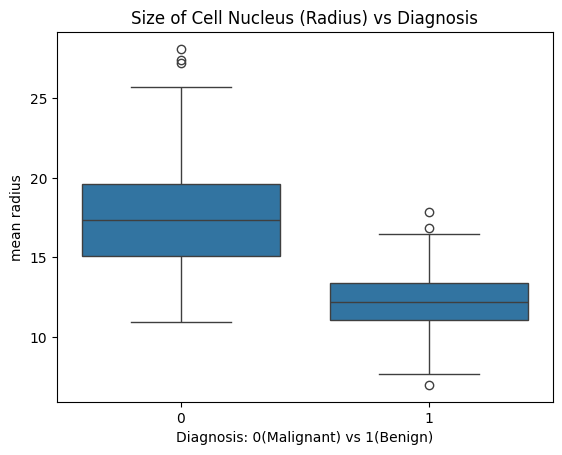

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 0 = Malignant (Cancer)
# 1 = Benign (non-cancerous)
sns.boxplot(x='target', y='mean radius', data=df)

plt.title("Size of Cell Nucleus (Radius) vs Diagnosis")
plt.xlabel("Diagnosis: 0(Malignant) vs 1(Benign)")
plt.show()
